Data Preprocessing - Python - 4/27/2026 - derave1577

In [1]:
# Import necessary libraries
import pandas as pd
from datetime import datetime
from IPython.display import display, Markdown
todays_date = datetime.now().strftime("%Y-%m-%d")
student_id = "derave1577"
# Load the Titanic dataset
data = pd.read_csv('titanic.csv')
# Display the first few rows to understand what the data looks like
display(Markdown("### Step 1.2: Load the Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
display(data.head())

### Step 1.2: Load the Dataset

Date: 2026-04-27

Student ID: derave1577

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
display(Markdown("### Step 1.3: Initial Exploration of the Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Get a concise summary of the DataFrame
print(data.info())
# Get descriptive statistics that summarize the central tendency, dispersion, and shape of the dataset's numerical features
display(data.describe())

### Step 1.3: Initial Exploration of the Dataset

Date: 2026-04-27

Student ID: derave1577

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [3]:
display(Markdown("### Step 2.1: Handling Missing Values"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Check for missing values in the dataset
missing_values = data.isnull().sum()
print(f"Missing values in each column:\n{missing_values}")
# Fill missing values for 'Age' with the median age
data['Age'] = data['Age'].fillna(data['Age'].median(), inplace=True)
# Fill missing values for 'Embarked' with the most common port
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)
# Drop ‘Cabin’ column due to significate number of missing values
data.drop(columns=['Cabin'], inplace=True)
# Verify that there are no remaining missing values
missing_values_after = data.isnull().sum()
print(f"Missing values after cleaning:\n{missing_values_after}")

### Step 2.1: Handling Missing Values

Date: 2026-04-27

Student ID: derave1577

Missing values in each column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64


C:\Users\Derek A\AppData\Local\Temp\ipykernel_65228\404891737.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data['Age'] = data['Age'].fillna(data['Age'].median(), inplace=True)
C:\Users\Derek A\AppData\Local\Temp\ipykernel_65228\404891737.py:10: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series thr

In [4]:
display(Markdown("### Step 2.2: Feature Engineering"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Create new feature 'FamilySize' as the sum of 'SibSp' and 'Parch'
data['FamilySize'] = data['SibSp'] + data['Parch']
# Create new feature 'IsAlone' (1 if alone, 0 otherwise)
data['IsAlone'] = 0
data.loc[data['FamilySize'] == 0, 'IsAlone'] = 1
# Drop 'SibSp' and 'Parch' as they are now redundant
data.drop(columns=['SibSp', 'Parch'], inplace=True)
# Display the first few rows to verify the changes
display(data.head())

### Step 2.2: Feature Engineering

Date: 2026-04-27

Student ID: derave1577

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,A/5 21171,7.2500,S,1,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,PC 17599,71.2833,C,1,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,STON/O2. 3101282,7.9250,S,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,113803,53.1000,S,1,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,373450,8.0500,S,0,1


In [5]:
from sklearn.preprocessing import OneHotEncoder
display(Markdown("### Step 3.1: Encoding Categorical Variables"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Initialize the OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, drop='first')
# Select categorical variables for encoding
categorical_features = data[['Pclass', 'Sex', 'Embarked']]
# Apply one-hot encoding
encoded_features = encoder.fit_transform(categorical_features)
# Convert the encoded features into a DataFrame
encoded_df = pd.DataFrame(encoded_features,
columns=encoder.get_feature_names_out(['Pclass', 'Sex', 'Embarked']))
# Drop original categorical columns and concatenate encoded features
data.drop(columns=['Pclass', 'Sex', 'Embarked'], inplace=True)
data = pd.concat([data, encoded_df], axis=1)
# Display the first few rows to verify the changes
display(data.head())

### Step 3.1: Encoding Categorical Variables

Date: 2026-04-27

Student ID: derave1577

,PassengerId,Survived,Name,Age,Ticket,Fare,FamilySize,IsAlone,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,Embarked_nan
0,1,0,"Braund, Mr. Owen Harris",22.0,A/5 21171,7.2500,1,0,0.0,1.0,1.0,0.0,1.0,0.0
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,PC 17599,71.2833,1,0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,1,"Heikkinen, Miss. Laina",26.0,STON/O2. 3101282,7.9250,0,1,0.0,1.0,0.0,0.0,1.0,0.0
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,113803,53.1000,1,0,0.0,0.0,0.0,0.0,1.0,0.0
4,5,0,"Allen, Mr. William Henry",35.0,373450,8.0500,0,1,0.0,1.0,1.0,0.0,1.0,0.0


In [6]:
from sklearn.preprocessing import StandardScaler
from IPython.display import display, Markdown

display(Markdown("### Step 3.2: Scaling Numerical Features (Bulletproof Edition)"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

scaler = StandardScaler()
numerical_features = ['Age', 'Fare', 'FamilySize']
scaled_data = data.copy()

# 1. Apply initial scaling
scaled_data[numerical_features] = scaler.fit_transform(data[numerical_features])

z_threshold = 3  # Standard threshold for extreme outliers
initial_count = len(scaled_data)

# 2. Calculate Z-Scores and filter using pure Pandas
for feature in numerical_features:
    mean = scaled_data[feature].mean()
    std = scaled_data[feature].std()
    
    # Guard against division by zero!
    if std == 0 or pd.isna(std):
        print(f"⚠️ Skipping {feature} because it has zero variance (all values are identical).")
        continue
        
    # Calculate Z-score manually (Pandas ignores NaNs automatically here)
    scaled_data[f'{feature}_Z'] = (scaled_data[feature] - mean) / std
    
    # Remove ONLY the rows that are actively outside the threshold.
    # The tilde (~) negates the condition. If a row is NaN, it stays!
    active_outliers = scaled_data[f'{feature}_Z'].abs() > z_threshold
    scaled_data = scaled_data[~active_outliers]

remaining_count = len(scaled_data)

# 3. Drop the z-score columns
scaled_data = scaled_data.drop(columns=[f'{feature}_Z' for feature in numerical_features if f'{feature}_Z' in scaled_data.columns])

# 4. Final safety check before re-scaling
if not scaled_data.empty:
    scaled_data[numerical_features] = scaler.fit_transform(scaled_data[numerical_features])
    display(scaled_data.head())
else:
    print("❌ Critical Error: Still no data left. Double check that your starting numerical columns actually contain varied data.")

### Step 3.2: Scaling Numerical Features (Bulletproof Edition)

Date: 2026-04-27

Student ID: derave1577

,PassengerId,Survived,Name,Age,Ticket,Fare,FamilySize,IsAlone,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,Embarked_nan
0,1,0,"Braund, Mr. Owen Harris",-0.589458,A/5 21171,-0.634276,0.269449,0,0.0,1.0,1.0,0.0,1.0,0.0
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0.706107,PC 17599,1.537099,0.269449,0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,1,"Heikkinen, Miss. Laina",-0.265567,STON/O2. 3101282,-0.611387,-0.617090,1,0.0,1.0,0.0,0.0,1.0,0.0
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0.463189,113803,0.920501,0.269449,0,0.0,0.0,0.0,0.0,1.0,0.0
4,5,0,"Allen, Mr. William Henry",0.463189,373450,-0.607148,-0.617090,1,0.0,1.0,1.0,0.0,1.0,0.0


### Step 3.3: Visualizing the Data Distribution

Date: 2026-04-27

Student ID: derave1577

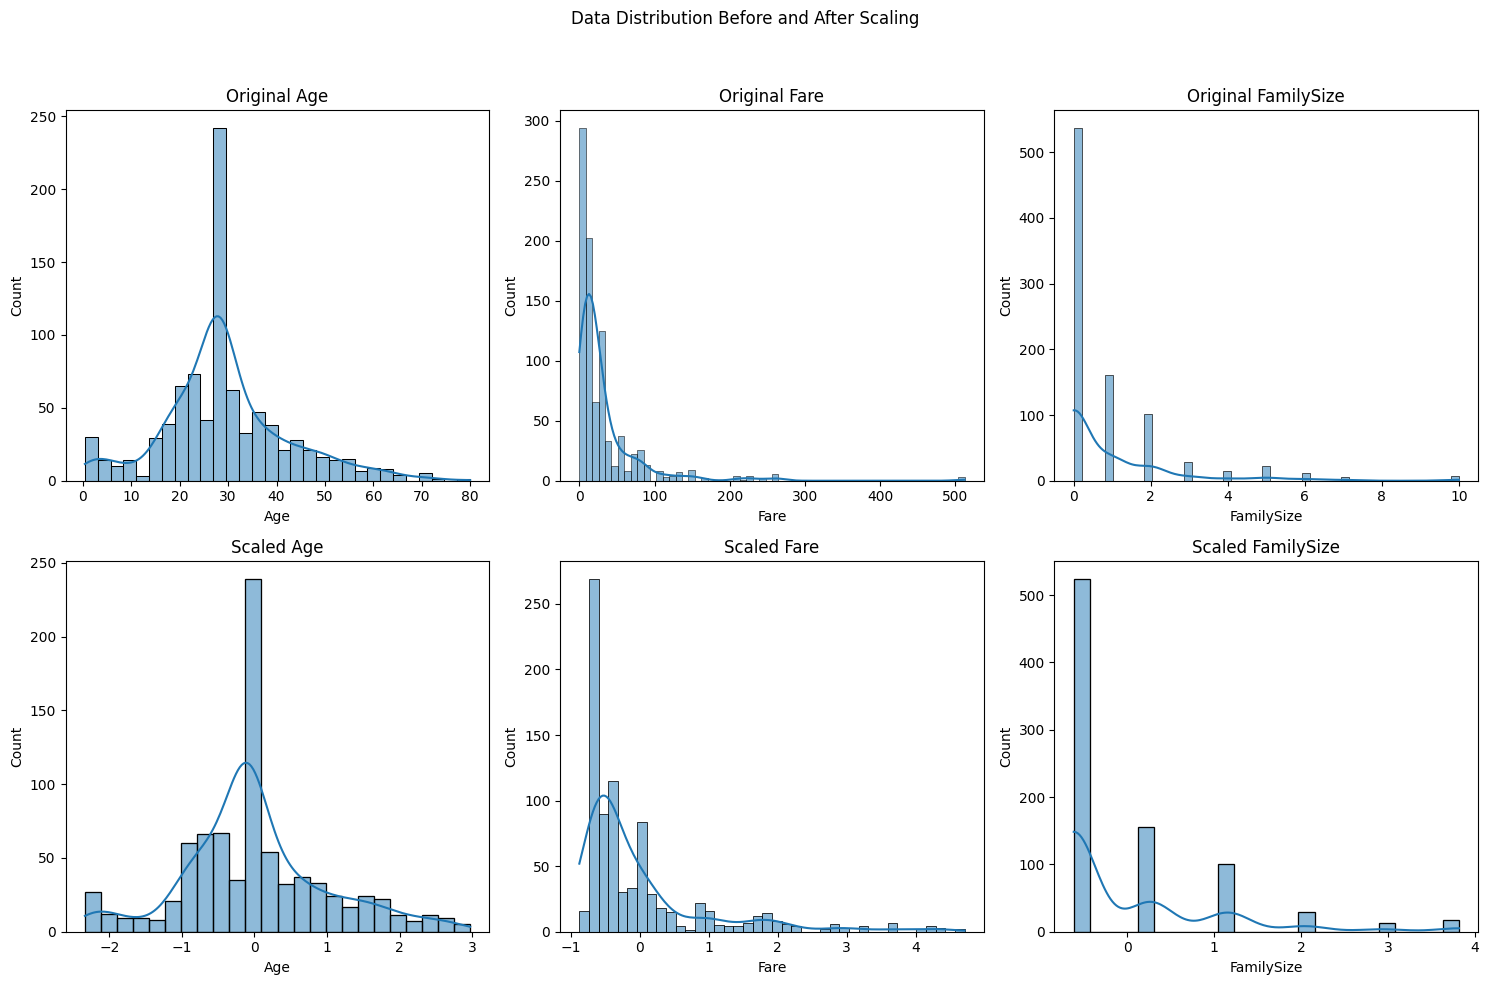

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
display(Markdown("### Step 3.3: Visualizing the Data Distribution"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Visualize the distribution of numerical features before and after scaling
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
fig.suptitle('Data Distribution Before and After Scaling')
# Original numerical features
for i, feature in enumerate(numerical_features):
    sns.histplot(data[feature], ax=axes[0, i], kde=True)
    axes[0, i].set_title(f'Original {feature}')
# Scaled numerical features with outliers removed
for i, feature in enumerate(numerical_features):
    sns.histplot(scaled_data[feature], ax=axes[1, i], kde=True)
    axes[1, i].set_title(f'Scaled {feature}')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
display(Markdown("### Step 3.4: Splitting the Data"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Update the main dataframe to use scaled features
data = scaled_data
# Drop unneccessary categorical features
data = data.drop(columns = ['Name', 'Ticket'])
# Preparing features (X) and target variable (y) from the prepared dataset
X = data.drop('Survived', axis=1)
y = data['Survived']
# Splitting the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Display the sizes of the training and test sets to verify the split
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

### Step 3.4: Splitting the Data

Date: 2026-04-27

Student ID: derave1577

Training set size: 671 samples
Test set size: 168 samples


In [9]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
display(Markdown("### Step 4.1: Training the SVM Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Define the parameter grid for hyperparameter tuning
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}
# Initialize the SVM model
svm = SVC()
# Initialize GridSearchCV with the SVM model and parameter grid
grid_search = GridSearchCV(svm, param_grid, refit=True, verbose=2, cv=5)
# Fit the model to the training data
grid_search.fit(X_train, y_train)
# Display the best parameters and best score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Score: {grid_search.best_score_}")

### Step 4.1: Training the SVM Model

Date: 2026-04-27

Student ID: derave1577

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
display(Markdown("### Step 4.2: Evaluating the SVM Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Make predictions on the test data
y_pred = grid_search.predict(X_test)
# Print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))
# Print the confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

### Step 4.2: Evaluating the SVM Model

Date: 2026-04-27

Student ID: derave1577

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.86      0.78       101
           1       0.70      0.48      0.57        67

    accuracy                           0.71       168
   macro avg       0.70      0.67      0.67       168
weighted avg       0.71      0.71      0.69       168

Confusion Matrix:
[[87 14]
 [35 32]]


In [16]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
display(Markdown("### Step 4.3: Training the XGBoost Regressor Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Split the data into features and target variable for regression
X_reg = data.drop('Fare', axis=1)
y_reg = data['Fare']
# Split the data into training and testing sets
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
# Define the parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}
# Initialize the XGBoost Regressor
xgb_reg = xgb.XGBRegressor()
# Initialize GridSearchCV with the XGBoost Regressor and parameter grid
grid_search_reg = GridSearchCV(xgb_reg, param_grid, refit=True,
verbose=2, cv=5)
# Fit the model to the training data
grid_search_reg.fit(X_train_reg, y_train_reg)
# Display the best parameters and best score
print(f"Best Parameters: {grid_search_reg.best_params_}")
print(f"Best Score: {grid_search_reg.best_score_}")

### Step 4.3: Training the XGBoost Regressor Model

Date: 2026-04-27

Student ID: derave1577

Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.0s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.0s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.0s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.0s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.0s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=200; total time=   0.0s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=200; total time=   0.0s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=200; total time=   0.0s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=200; total time=   0.0s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=200; total time=   0.0s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=300; total time=   0.0s
[CV] END ..learning_rate=0.01, max_depth=3, n_e

### Step 4.4: Evaluating the XGBoost Regressor Model

Date: 2026-04-27

Student ID: derave1577

Mean Squared Error: 0.4207819344531886
R² Score: 0.6856084879812254


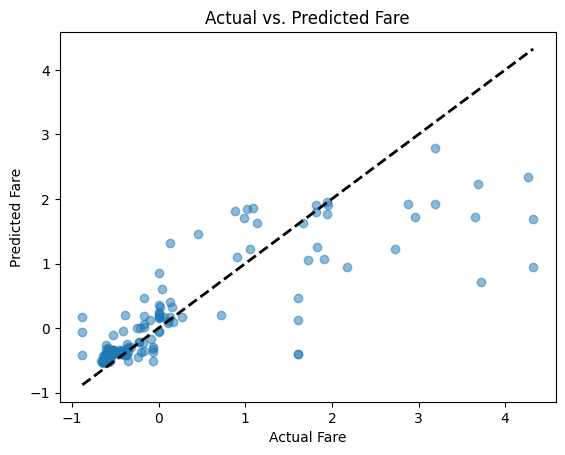

In [17]:
from sklearn.metrics import mean_squared_error, r2_score
display(Markdown("### Step 4.4: Evaluating the XGBoost Regressor Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Make predictions on the test data
y_pred_reg = grid_search_reg.predict(X_test_reg)
# Calculate and print evaluation metrics
mse = mean_squared_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)
print(f"Mean Squared Error: {mse}")
print(f"R² Score: {r2}")
# Visualization of actual vs. predicted values
plt.scatter(y_test_reg, y_pred_reg, alpha=0.5)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'k--', lw=2)
plt.xlabel('Actual Fare')
plt.ylabel('Predicted Fare')
plt.title('Actual vs. Predicted Fare')
plt.show()